# Purpose of the Code

The goal of this notebook is to extract EMG signals recorded using Trigno system, process the raw data, extract meaningful features, and store the resulting information in a structured DataFrame format.

## Environment Setup

In [99]:
# pip install libemg  # Required only if you have never installed the libemg package
# pip install --upgrade paramiko cryptography  # Needed during first-time installation of libemg to resolve dependencies

In [100]:
import os
import pandas as pd
import numpy as np
import sys
sys.path.append('../../lib')
from import_emg_file import import_data_from_trigno
from trigno_utils import trigno_dataframe_edit, trigno_extract_muscle_emg
from emg_utils import plot_emg_signal, emg_filters, extract_emg_windows_v2, extract_emg_features
from features_utils import combine_multiple_features_lists, detect_segments_v2, assign_emg_labels_v2

In [101]:
# Parameters
subj = "01"
date = "07_03"
folder = "Seq4"
intensity_level = ["heavy", "light", "medium"] # Weights sequence
muscle_names = ["biceps", "triceps"]  # Target muscle: "biceps", "triceps", "forearm1", or "forearm2"
muscle_ref = "biceps" # Reference muscle for true label assignment
lenght = 28 # n° of "interesting" columns of CSV file

w_d = 0.2  # Window duration in seconds for feature extraction
ov = 0.5  # Overlap percentage between windows (e.g., 0.5 = 50%)
step = w_d * ov
n_lifts = 5  # Number of lifts
duration = 70
rest = 60 
n_segments = 3
windows_s = [(i * (duration + rest) + 5.0, i * (duration + rest) + duration + 5.0) for i in range(n_segments)]
windows_idx_list = [] 
fs_list = []  # Initialize list to store sampling frequencies

# Feature lists
features_list_norm = ['MAV', 'WL', 'RMS', 'VAR', 'IAV', 'LD', 'SAMPEN', 'MPK']  # Features on normalized signal
features_list_filt = ['ZC', 'SSC', 'KURT', 'SKEW', 'WAMP']  # Features on filtered signal
features_list_freq = ['MNF', 'MNP', 'SM', 'ISD']  # Frequency-domain features

# Paths for input and output
input_folder = f'../../data/acquisitions/trigno/{date}/S{subj}/{folder}/'  # Input folder with raw data
output_folder = f'../../data/extracted_features/trigno/S{subj}_{date}/features'  # Output folder to save extracted features
output_filename = f"features_{folder}.csv"  # Name of the output CSV file
mvc = f'../../data/mvc_values/trigno/S{subj}_{date}/combined_dataset2.csv' # Name of the mvc dataset

# Loading Data Files

In [102]:
dataframes = import_data_from_trigno(input_folder, lenght)  # Import raw data from Trigno folder
dataframes = [trigno_dataframe_edit(df) for df in dataframes]  # Format each imported dataframe

In [103]:
muscle_emg_raw, emg_time = trigno_extract_muscle_emg(dataframes, muscle_names)  # Extract EMG signals and timestamps for the specified muscle

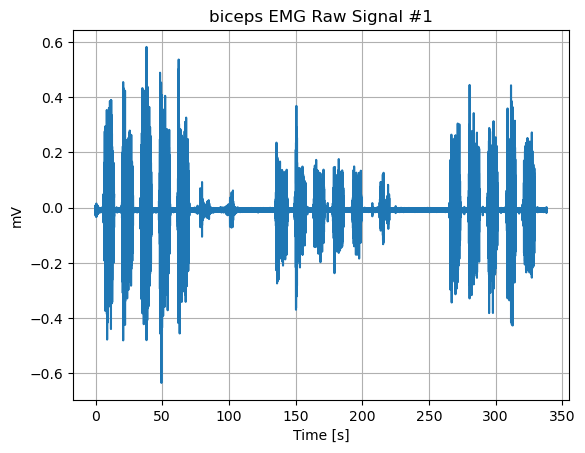

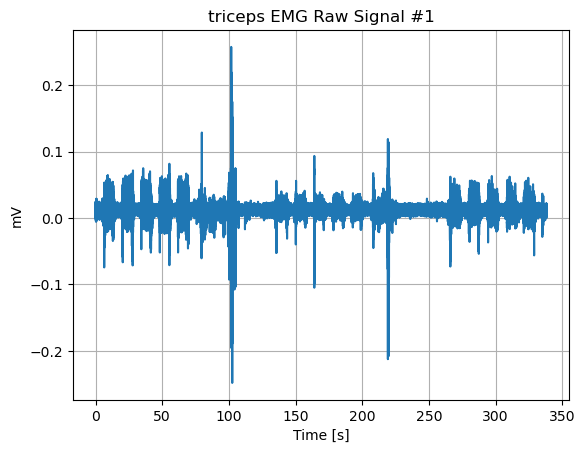

In [104]:
for i in range(len(emg_time)):
    for muscle in muscle_names:
        emg_signal = muscle_emg_raw[muscle][i]
        time_vector = emg_time[i]
        plot_emg_signal(emg_signal, time_vector, title=f"{muscle} EMG Raw Signal #{i+1}")

# EMG Signal Analysis

## Filtering, Rectification, Smoothing and Normalization

In [105]:
for time in emg_time:
    fs = 1.0 / np.mean(np.diff(time))  # Calculate sampling frequency from time intervals
    windows_idx = [(int(fs * start), int(fs * end)) for start, end in windows_s] # Convert to indices using sampling frequency
    windows_idx_list.append(windows_idx)
    fs_list.append(fs)  
fs_list_ext = [fs for fs in fs_list for _ in range(n_segments)]

In [106]:
muscle_emg_filtered, _, _, muscle_emg_normalized = emg_filters(muscle_emg_raw, emg_time, fs_list, muscle_names, mvc)  # Filter EMG signals

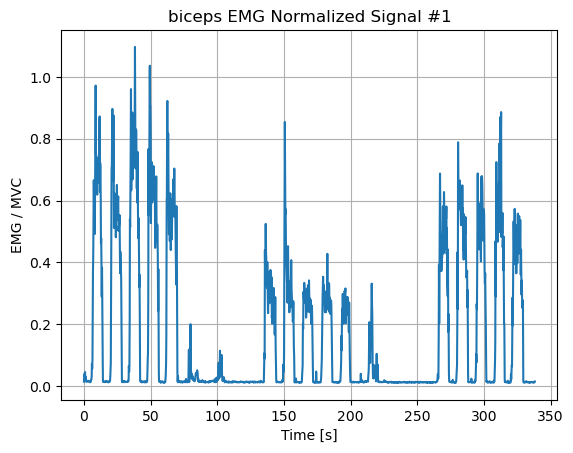

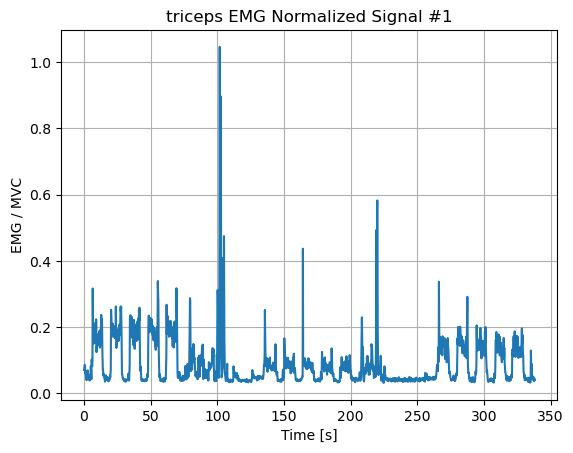

In [107]:
for i in range(len(emg_time)):
    for muscle in muscle_names:
        emg_signal = muscle_emg_normalized[muscle][i]
        time_vector = emg_time[i]
        plot_emg_signal(emg_signal, time_vector, title=f"{muscle} EMG Normalized Signal #{i+1}", ylabel="EMG / MVC")

## Windowing and Features Extraction

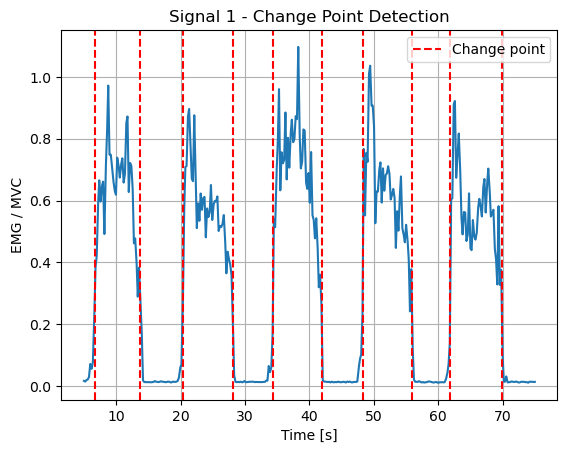

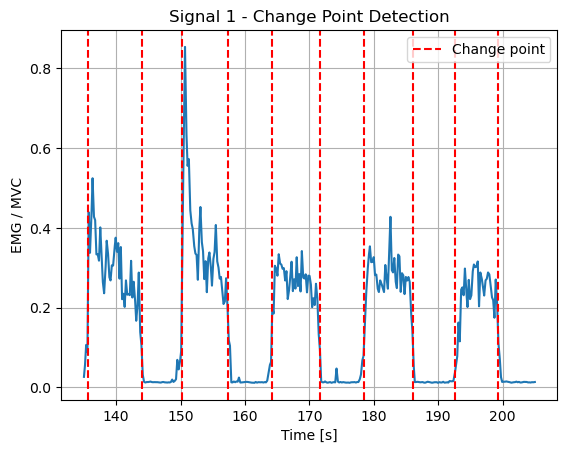

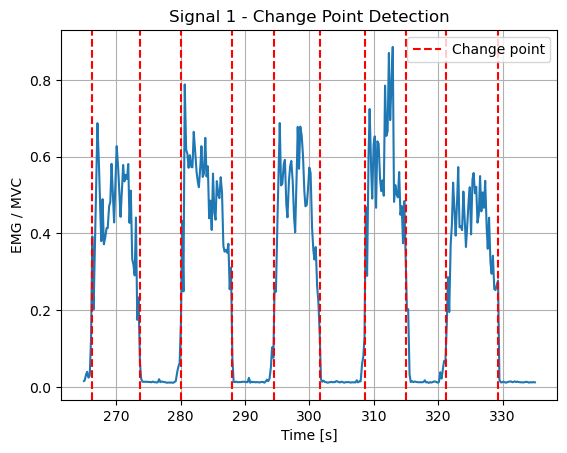

In [108]:
emg_norm_cut, emg_filt_cut, emg_time_cut, breakpoints = detect_segments_v2(
    emg_time, muscle_emg_normalized, muscle_emg_filtered, muscle_names, muscle_ref, windows_idx_list, intensity_level, n_lifts, fs_list, flag=True)

In [109]:
normalized_win, filtered_win, time_win = extract_emg_windows_v2(emg_norm_cut, emg_filt_cut, emg_time_cut, fs_list_ext, 
                                                                window_duration=w_d, overlap=ov)

In [110]:
# Features Extraction
time_features_norm = extract_emg_features(normalized_win, features_list_norm)  # Extract time-domain features from normalized EMG windows
time_features_filt = extract_emg_features(filtered_win, features_list_filt)  # Extract time-domain features from filtered EMG windows
freq_features_norm = extract_emg_features(normalized_win, features_list_freq)  # Extract frequency-domain features from normalized EMG windows

In [111]:
dfs = combine_multiple_features_lists(time_features_norm, time_features_filt, freq_features_norm)  # Combine all feature lists into a single dataframe

## Label Assignment

In [112]:
first_key, first_value = next(iter(normalized_win.items()))
windows_per_segment = int(len(first_value)/(n_segments *len(emg_time)))
dfs['label'] = assign_emg_labels_v2(breakpoints, windows_per_segment, fs_list_ext, w_d, ov, intensity_level, n_lifts)

# Features Export

In [113]:
output_path = os.path.join(output_folder, output_filename)  # Create full path for output CSV file
dfs.to_csv(output_path, index=False)  # Save dataframe with features and labels to CSV